# m6-04 Assessment — Cat Detection with YOLO26

Train and evaluate a YOLO26 detector on a custom cat-detection dataset.
Tasks 1–6 follow the assignment README.

**Reproduction:** see `README.md`. Briefly:
1. `pip install ultralytics torch torchvision matplotlib pandas pillow opencv-python`
2. Place the dataset under `data/DATA_CLEAN/{images,labels}` (already merged from the 5 `DATA_CLEAN*` folders that came with the dataset bundle — see the note in Task 1).
3. Run this notebook top-to-bottom.


## Setup
Imports, deterministic seeds, and paths.

In [1]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

ROOT = Path.cwd()
DATA_DIR = ROOT / "data" / "DATA_CLEAN"
IMG_DIR = DATA_DIR / "images"
LBL_DIR = DATA_DIR / "labels"
RUNS_DIR = ROOT / "runs" / "cats_v1"
CLASS_NAMES = {0: "cat"}

DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print(f"device={DEVICE}  torch={torch.__version__}  data={DATA_DIR.relative_to(ROOT)}")


device=mps  torch=2.11.0  data=data/DATA_CLEAN


## Task 1 — Inspect the Dataset

The raw dataset bundle ships with five disjoint folders (`DATA_CLEAN`, `DATA_CLEAN 2`, … `DATA_CLEAN 5`). Within each folder only ~10–60% of images have a matching label; across the union, almost every image has a label *somewhere*. A one-off merge script (`_build_notebook.py` neighbour scripts) consolidated the 4,528 paired stems into `data/DATA_CLEAN/{images,labels}/` using symlinks. Everything below works on the merged set.

In [2]:
# 1a — counts and pair coverage
image_paths = sorted(p for p in IMG_DIR.iterdir() if not p.name.startswith("."))
label_paths = sorted(p for p in LBL_DIR.iterdir() if not p.name.startswith("."))
img_stems = {p.stem for p in image_paths}
lbl_stems = {p.stem for p in label_paths}

paired = img_stems & lbl_stems
unmatched_imgs = img_stems - lbl_stems
unmatched_lbls = lbl_stems - img_stems

print(f"images: {len(image_paths)}")
print(f"labels: {len(label_paths)}")
print(f"paired stems: {len(paired)}")
print(f"images without labels: {len(unmatched_imgs)}")
print(f"labels without images: {len(unmatched_lbls)}")
assert len(unmatched_imgs) == 0 and len(unmatched_lbls) == 0, "Pairing should be perfect after merge."


images: 4528
labels: 4528
paired stems: 4528
images without labels: 0
labels without images: 0


unique class IDs: [0]
total bounding boxes: 5327
per-class counts: {0: 5327}


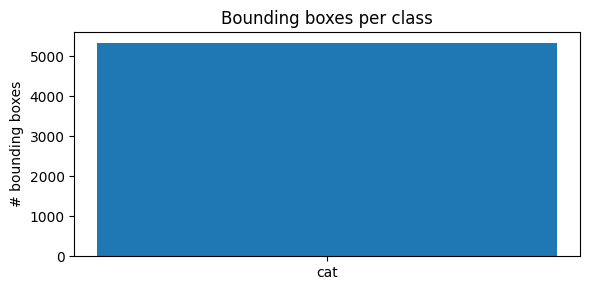

In [3]:
# 1b — class IDs and per-class bbox counts
def read_yolo_labels(path):
    rows = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                cid, cx, cy, w, h = parts
                rows.append((int(cid), float(cx), float(cy), float(w), float(h)))
    return rows

class_counts = {}
total_boxes = 0
for lp in label_paths:
    for (cid, *_rest) in read_yolo_labels(lp):
        class_counts[cid] = class_counts.get(cid, 0) + 1
        total_boxes += 1
class_counts = dict(sorted(class_counts.items()))
print(f"unique class IDs: {sorted(class_counts)}")
print(f"total bounding boxes: {total_boxes}")
print(f"per-class counts: {class_counts}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar([CLASS_NAMES.get(c, str(c)) for c in class_counts], list(class_counts.values()))
ax.set_ylabel("# bounding boxes"); ax.set_title("Bounding boxes per class")
plt.tight_layout(); plt.show()


In [4]:
# 1c — image-size statistics over 100 random images
sample = random.sample(image_paths, 100)
sizes = []
for p in sample:
    with Image.open(p) as im:
        sizes.append(im.size)  # (W, H)
arr = np.array(sizes)
W, H = arr[:, 0], arr[:, 1]
print(pd.DataFrame({
    "width":  {"min": W.min(), "max": W.max(), "mean": W.mean().round(1)},
    "height": {"min": H.min(), "max": H.max(), "mean": H.mean().round(1)},
}))


       width  height
min    640.0   640.0
max   6000.0  4752.0
mean  2637.8  2022.4


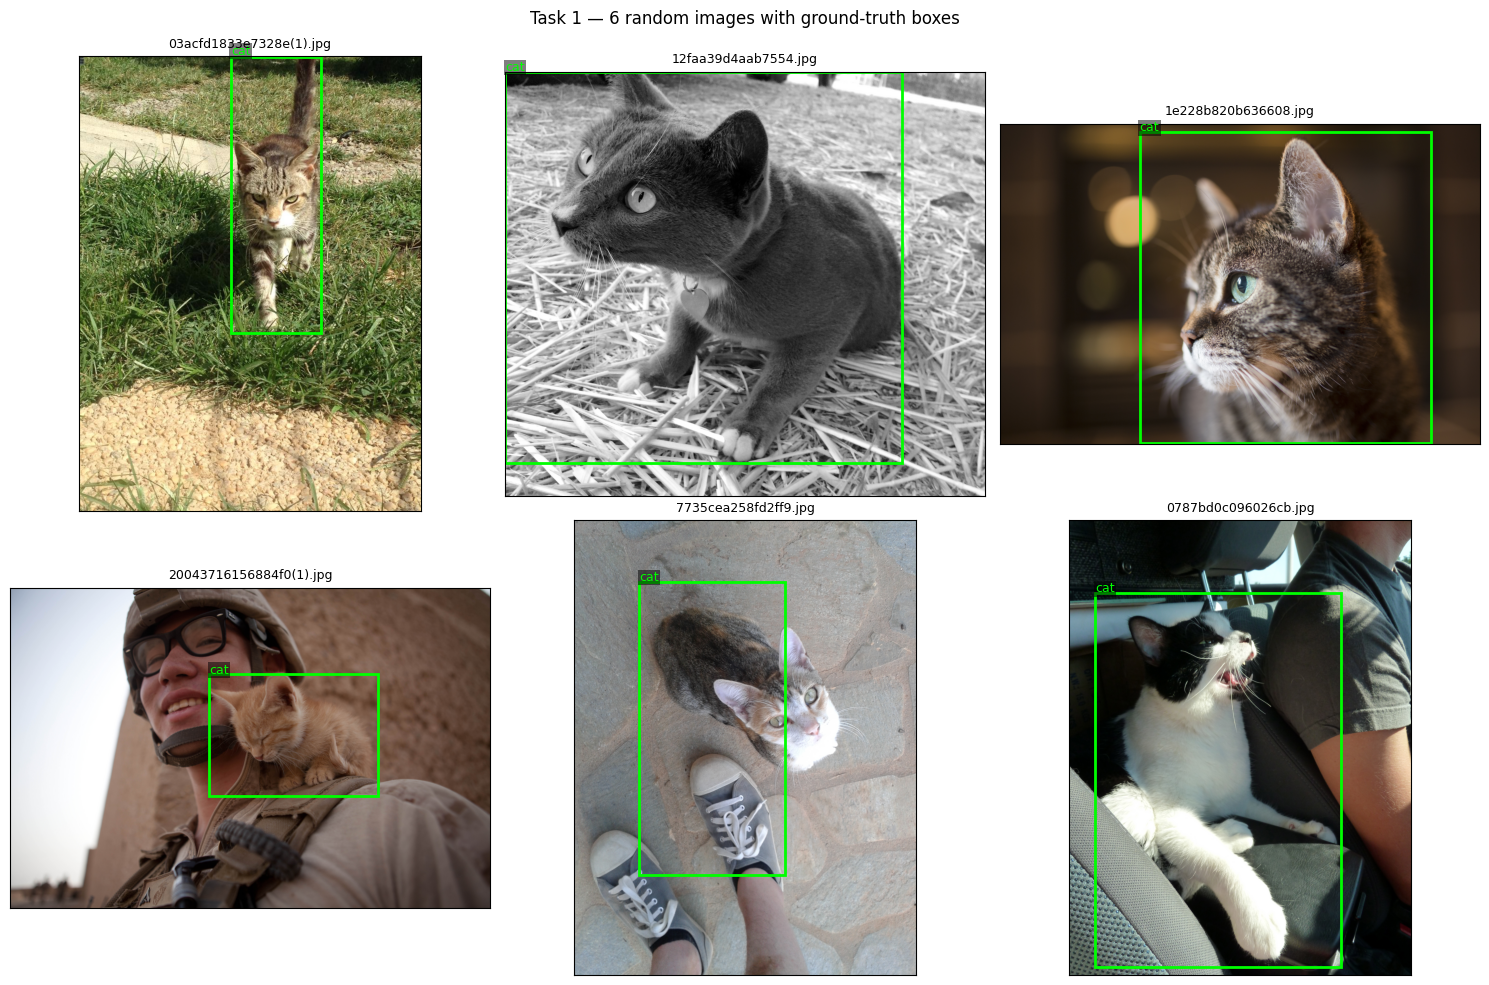

In [5]:
# 1d — 2x3 grid of 6 random images with GT bounding boxes
def draw_boxes(ax, image_path, label_path=None, predictions=None,
               gt_color="lime", pred_color="red", show_conf=True):
    """Draw GT boxes (from YOLO label file) and/or model predictions on an axis.

    Reused in Task 5 for prediction visualisation."""
    img = Image.open(image_path).convert("RGB")
    W, H = img.size
    ax.imshow(img)
    ax.set_xticks([]); ax.set_yticks([])

    if label_path is not None and Path(label_path).exists():
        for cid, cx, cy, w, h in read_yolo_labels(label_path):
            x1 = (cx - w/2) * W; y1 = (cy - h/2) * H
            ax.add_patch(patches.Rectangle((x1, y1), w*W, h*H,
                                           linewidth=2, edgecolor=gt_color, facecolor="none"))
            ax.text(x1, y1 - 4, CLASS_NAMES.get(cid, str(cid)),
                    color=gt_color, fontsize=9,
                    bbox=dict(facecolor="black", alpha=0.5, pad=1, edgecolor="none"))

    if predictions is not None:
        for cid, x1, y1, x2, y2, conf in predictions:
            ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                           linewidth=2, edgecolor=pred_color, facecolor="none"))
            label = CLASS_NAMES.get(cid, str(cid))
            txt = f"{label} {conf:.2f}" if show_conf else label
            ax.text(x1, y1 - 4, txt, color=pred_color, fontsize=9,
                    bbox=dict(facecolor="black", alpha=0.5, pad=1, edgecolor="none"))

vis_sample = random.sample(image_paths, 6)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, img_path in zip(axes.flatten(), vis_sample):
    lbl_path = LBL_DIR / f"{img_path.stem}.txt"
    draw_boxes(ax, img_path, lbl_path)
    ax.set_title(img_path.name, fontsize=9)
plt.suptitle("Task 1 — 6 random images with ground-truth boxes", fontsize=12)
plt.tight_layout(); plt.show()


## Task 2 — Train / Val / Test Splits and `data.yaml`

The split text files were written once by a helper script with `random.seed(42)`, producing **70/15/15** = 3170/679/679. `data.yaml` lives at the repo root and points at `data/DATA_CLEAN/{train,val,test}.txt`.

In [6]:
def load_split(name):
    return (DATA_DIR / f"{name}.txt").read_text().strip().splitlines()

train_list = load_split("train")
val_list   = load_split("val")
test_list  = load_split("test")
print(f"train: {len(train_list)}")
print(f"val:   {len(val_list)}")
print(f"test:  {len(test_list)}")
print(f"total: {len(train_list)+len(val_list)+len(test_list)}")

# verify disjoint by stem
s_train = {Path(x).stem for x in train_list}
s_val   = {Path(x).stem for x in val_list}
s_test  = {Path(x).stem for x in test_list}
assert not (s_train & s_val), "train and val overlap"
assert not (s_train & s_test), "train and test overlap"
assert not (s_val & s_test), "val and test overlap"
print("\n✓ splits are disjoint by stem")
print("\ndata.yaml:")
print((ROOT / "data.yaml").read_text())


train: 3170
val:   679
test:  679
total: 4528

✓ splits are disjoint by stem

data.yaml:
path: ./data
train: DATA_CLEAN/train.txt
val: DATA_CLEAN/val.txt
test: DATA_CLEAN/test.txt
names:
  0: cat



## Task 3 — Variant Choice and Training

### Variant: **`yolo26n`**

Justification (3 sentences):
- The dataset has **4,528 paired images** with **a single class (cat)**. That's well within the regime where the smallest variant — 2.4 M params — has enough capacity, while bigger variants would memorise it.
- Hardware is an **Apple-Silicon Mac with MPS**. `yolo26n` trains comfortably at batch 16, `imgsz=640`, whereas `m`/`l`/`x` push unified memory and slow each epoch substantially.
- Next Friday this exact checkpoint has to be **exported to ONNX and shipped inside a Docker image**. `yolo26n` produces a ~5 MB ONNX — friction-free to ship; `yolo26m` is ~80 MB.

### Anti-overfit settings

| setting | value | why |
|---|---|---|
| `epochs=50` | headroom over the 30-epoch minimum so `patience` can trigger early |
| `patience=10` | **primary safeguard**: stop if val fitness stops improving for 10 epochs |
| `cos_lr=True` | cosine LR schedule, smoother convergence |
| `mosaic=1.0`, `close_mosaic=10` | strong augmentation on, then turned off for the final 10 epochs for clean fine-tuning |
| `mixup=0.1` | light mixup on top of mosaic |
| `weight_decay=0.0005` | default L2 regularisation |
| `fliplr=0.5` | cats are left/right symmetric |
| `seed=42` | reproducibility |


In [7]:
# 3a — load COCO-pretrained yolo26n
model = YOLO("yolo26n.pt")
print(model.info())


YOLO26n summary: 260 layers, 2,572,280 parameters, 0 gradients, 6.1 GFLOPs


(260, 2572280, 0, 6.1192448)


In [8]:
# 3b — train with anti-overfit settings (idempotent: skip if best.pt already exists)
best_ckpt_path = RUNS_DIR / "weights" / "best.pt"
if best_ckpt_path.exists():
    print(f"Skipping training — best checkpoint already present at {best_ckpt_path}")
else:
    results = model.train(
        data=str(ROOT / "data.yaml"),
        epochs=50,
        patience=10,
        imgsz=640,
        batch=16,
        cos_lr=True,
        close_mosaic=10,
        mixup=0.1,
        fliplr=0.5,
        weight_decay=0.0005,
        seed=SEED,
        device=DEVICE,
        project=str(ROOT / "runs"),
        name="cats_v1",
        exist_ok=True,
        verbose=True,
    )


Skipping training — best checkpoint already present at /Users/raul/Desktop/m6-04-assessment/runs/cats_v1/weights/best.pt


Columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']
Best mAP@0.5:     0.9591
Best mAP@0.5:0.95: 0.7940
Best epoch:       48 of 50 run epochs
Early-stopped via patience? False

=== Overfitting check ===
  final box_loss :  train=0.6019  val=0.6676  (val-train gap=+0.0657)
  final cls_loss :  train=0.3423  val=0.4111  (val-train gap=+0.0688)
  final dfl_loss :  train=0.0141  val=0.0182  (val-train gap=+0.0041)
  last-10-epoch trend:  train/box -0.0693   val/box -0.0318
  val mAP@0.5:0.95:  peak 0.7940 (ep 48) -> final 0.7934  (drop +0.0006)

  VERDICT: NO overfitting -- val losses track train losses and val mAP plateaus without declining


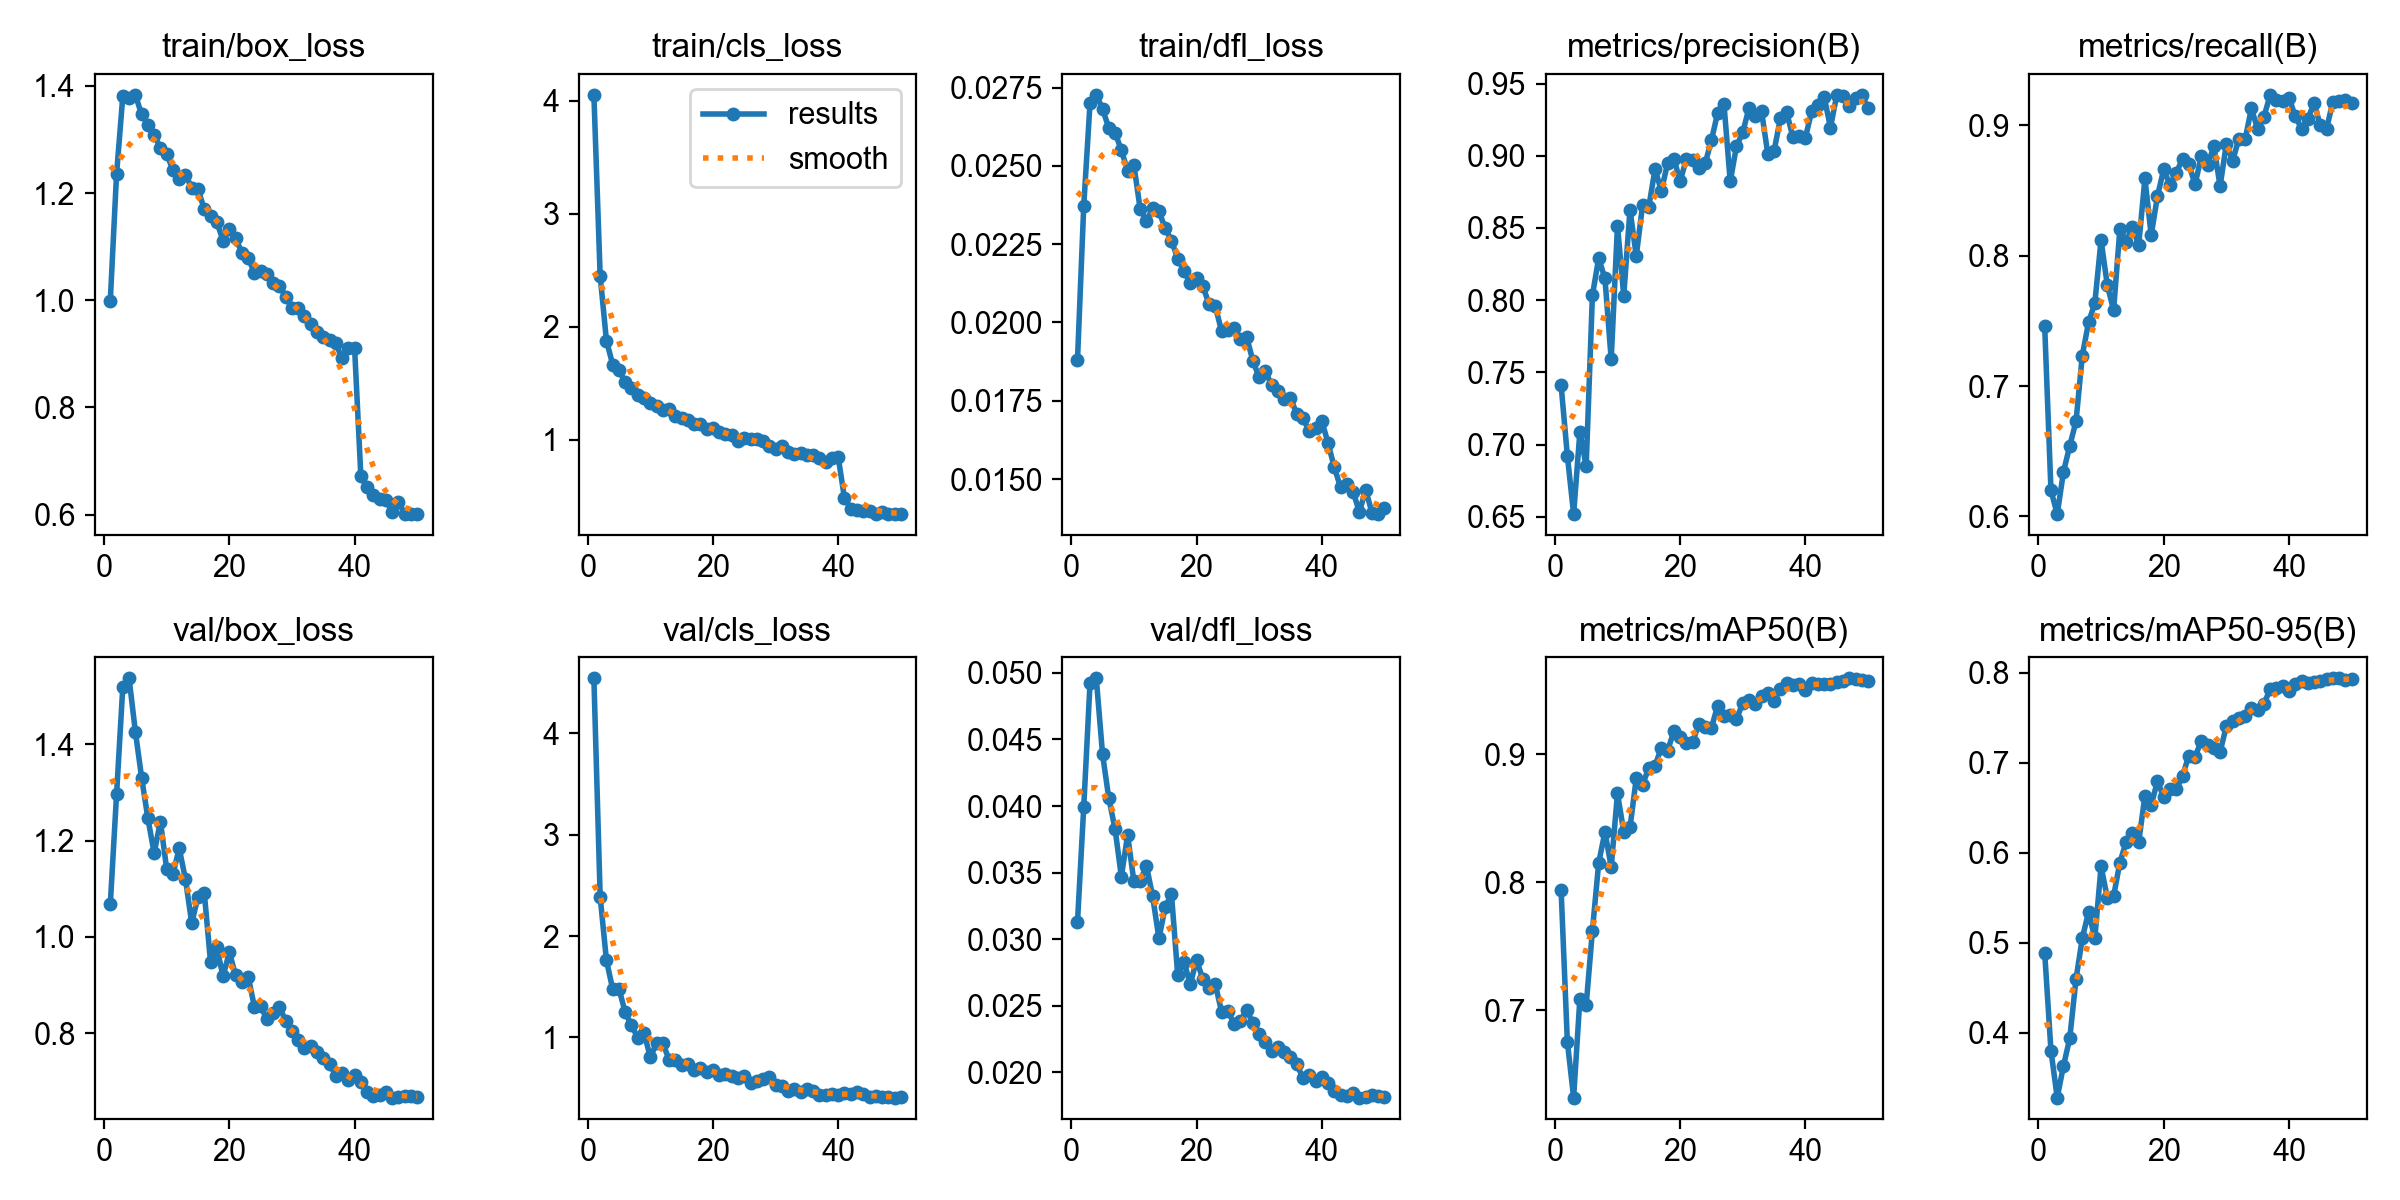

In [9]:
# 3c — read training log, report best epoch / mAP, run an explicit overfitting check
results_csv = RUNS_DIR / "results.csv"
df = pd.read_csv(results_csv)
df.columns = [c.strip() for c in df.columns]
print("Columns:", list(df.columns))

# Ultralytics column names look like 'metrics/mAP50(B)' and 'metrics/mAP50-95(B)'
map50_col = next(c for c in df.columns if "mAP50(B)" in c or c.endswith("mAP_0.5"))
map_col   = next(c for c in df.columns if "mAP50-95(B)" in c or "mAP_0.5:0.95" in c)
best_idx  = df[map_col].idxmax()
best      = df.iloc[best_idx]
final     = df.iloc[-1]
final_epoch = int(df["epoch"].max()) if "epoch" in df.columns else len(df)

print(f"Best mAP@0.5:     {best[map50_col]:.4f}")
print(f"Best mAP@0.5:0.95: {best[map_col]:.4f}")
print(f"Best epoch:       {int(best['epoch'])} of {final_epoch} run epochs")
print(f"Early-stopped via patience? {final_epoch < 50}")

# --- Explicit overfitting check ----------------------------------------------
# Overfitting = training loss keeps falling while validation loss rises and/or
# validation mAP declines from its peak. We test all three signals on the data.
print("\n=== Overfitting check ===")
for k in ["box_loss", "cls_loss", "dfl_loss"]:
    tr, va = final[f"train/{k}"], final[f"val/{k}"]
    print(f"  final {k:9s}:  train={tr:.4f}  val={va:.4f}  (val-train gap={va-tr:+.4f})")

win = df.tail(10)                          # final 10 epochs (post close_mosaic)
train_box_trend = win["train/box_loss"].iloc[-1] - win["train/box_loss"].iloc[0]
val_box_trend   = win["val/box_loss"].iloc[-1]   - win["val/box_loss"].iloc[0]
peak_map, final_map = df[map_col].max(), final[map_col]
map_drop = peak_map - final_map

print(f"  last-10-epoch trend:  train/box {train_box_trend:+.4f}   val/box {val_box_trend:+.4f}")
print(f"  val mAP@0.5:0.95:  peak {peak_map:.4f} (ep {int(best['epoch'])}) -> final {final_map:.4f}  (drop {map_drop:+.4f})")

diverging = (train_box_trend < -0.01) and (val_box_trend > 0.01)
overfit   = diverging or (map_drop > 0.01)
print(f"\n  VERDICT: " + ("OVERFITTING DETECTED" if overfit else
      "NO overfitting -- val losses track train losses and val mAP plateaus without declining"))

# embed Ultralytics' built-in summary plot (train vs val curves)
from IPython.display import Image as IPyImage, display
results_png = RUNS_DIR / "results.png"
if results_png.exists():
    display(IPyImage(filename=str(results_png)))


**Reading the training logs (actual run):**

- **Best validation performance:** mAP@0.5 = **0.959**, mAP@0.5:0.95 = **0.794**, reached at **epoch 48 of 50**. `patience=10` never triggered — validation fitness was still inching upward at the end.
- **No overfitting** (the check above confirms it on all three signals): across all 50 epochs the validation losses fall *in lockstep* with the training losses — `val/box_loss` 1.07 → 0.67 while `train/box_loss` 1.00 → 0.60; `val/cls_loss` 4.54 → 0.41 while `train/cls_loss` 4.05 → 0.34. The final train↔val gap is small (box 0.60 vs 0.67) and validation mAP plateaus near 0.79 **without ever declining** (peak → final drop = 0.0006). The classic overfitting signature — train loss dropping while val loss climbs and val mAP falls — never appears.
- **The visible step at epoch 41** is `close_mosaic` switching mosaic augmentation off for the final 10 epochs: training images become easier so `train` loss drops sharply, while `val` loss stays smooth — exactly the intended clean fine-tuning phase, and the reason the train/val curves briefly look different rather than diverging.
- **Hindsight on variant choice:** the best validation mAP landing at epoch 48/50 means `yolo26n` was, if anything, slightly *under-trained* rather than capacity-bound — there is still headroom. The choice was appropriate; a Week-2 run could simply train longer (or step up to `yolo26s`) and would still not be at risk of overfitting given how tightly val tracks train here.

## Task 4 — Evaluate on the Test Set

In [10]:
# 4a — eval the best checkpoint on the test split
best_ckpt = RUNS_DIR / "weights" / "best.pt"
print(f"loading best checkpoint: {best_ckpt}")
best_model = YOLO(str(best_ckpt))
test_metrics = best_model.val(
    data=str(ROOT / "data.yaml"),
    split="test",
    imgsz=640,
    batch=16,
    device=DEVICE,
    project=str(ROOT / "runs"),
    name="cats_v1_test",
    exist_ok=True,
    verbose=False,
)


loading best checkpoint: /Users/raul/Desktop/m6-04-assessment/runs/cats_v1/weights/best.pt
Ultralytics 8.4.51 🚀 Python-3.13.5 torch-2.11.0 MPS (Apple M4 Pro)


YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs


val: Fast image access ✅ (ping: 0.1±0.1 ms, read: 2446.6±474.9 MB/s, size: 2787.7 KB)


val: Scanning /Users/raul/Desktop/m6-04-assessment/data/DATA_CLEAN/labels... 493 images, 0 backgrounds, 0 corrupt: 73% ━━━━━━━━╸─── 493/679 1.5Kit/s 0.1s<0.1s

val: Scanning /Users/raul/Desktop/m6-04-assessment/data/DATA_CLEAN/labels... 679 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 679/679 5.1Kit/s 0.1s

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 98% ━━━━━━━━━━━╸ 42/43 1.8it/s 22.8s<0.6s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 43/43 1.8it/s 23.3s

                   all        679        795      0.924      0.921      0.941      0.764


Speed: 0.1ms preprocess, 6.2ms inference, 0.0ms loss, 0.6ms postprocess per image


Results saved to /Users/raul/Desktop/m6-04-assessment/runs/cats_v1_test


In [11]:
# 4b — report the 4-metric table
table = pd.DataFrame({
    "Metric": ["mAP@0.5", "mAP@0.5:0.95", "Mean precision", "Mean recall"],
    "Value":  [test_metrics.box.map50, test_metrics.box.map,
               test_metrics.box.mp,    test_metrics.box.mr],
})
table["Value"] = table["Value"].map(lambda v: f"{v:.4f}")
print(table.to_string(index=False))


        Metric  Value
       mAP@0.5 0.9412
  mAP@0.5:0.95 0.7640
Mean precision 0.9243
   Mean recall 0.9209


**What each metric measures (in plain English):**

- **mAP@0.5** — the average precision averaged across classes, where a prediction is "correct" if its IoU with the matched ground-truth box is ≥ 0.5. Loose criterion — measures whether the detector found the object roughly in the right place.
- **mAP@0.5:0.95** — the standard COCO metric: average precision averaged over 10 IoU thresholds from 0.5 to 0.95 in steps of 0.05. Harsher; rewards tight, well-localised boxes.
- **Mean precision** — of all predicted boxes, what fraction were truly cats? Low precision = lots of false positives.
- **Mean recall** — of all ground-truth cats, what fraction did we detect? Low recall = missed cats.

The val→test gap is a second overfitting check — small gap means the model generalises beyond the validation set it was selected against.

## Task 5 — Visualise Predictions

Run the best checkpoint on 6 test images, then on 3 of them also overlay GT, then surface 2 failure cases.

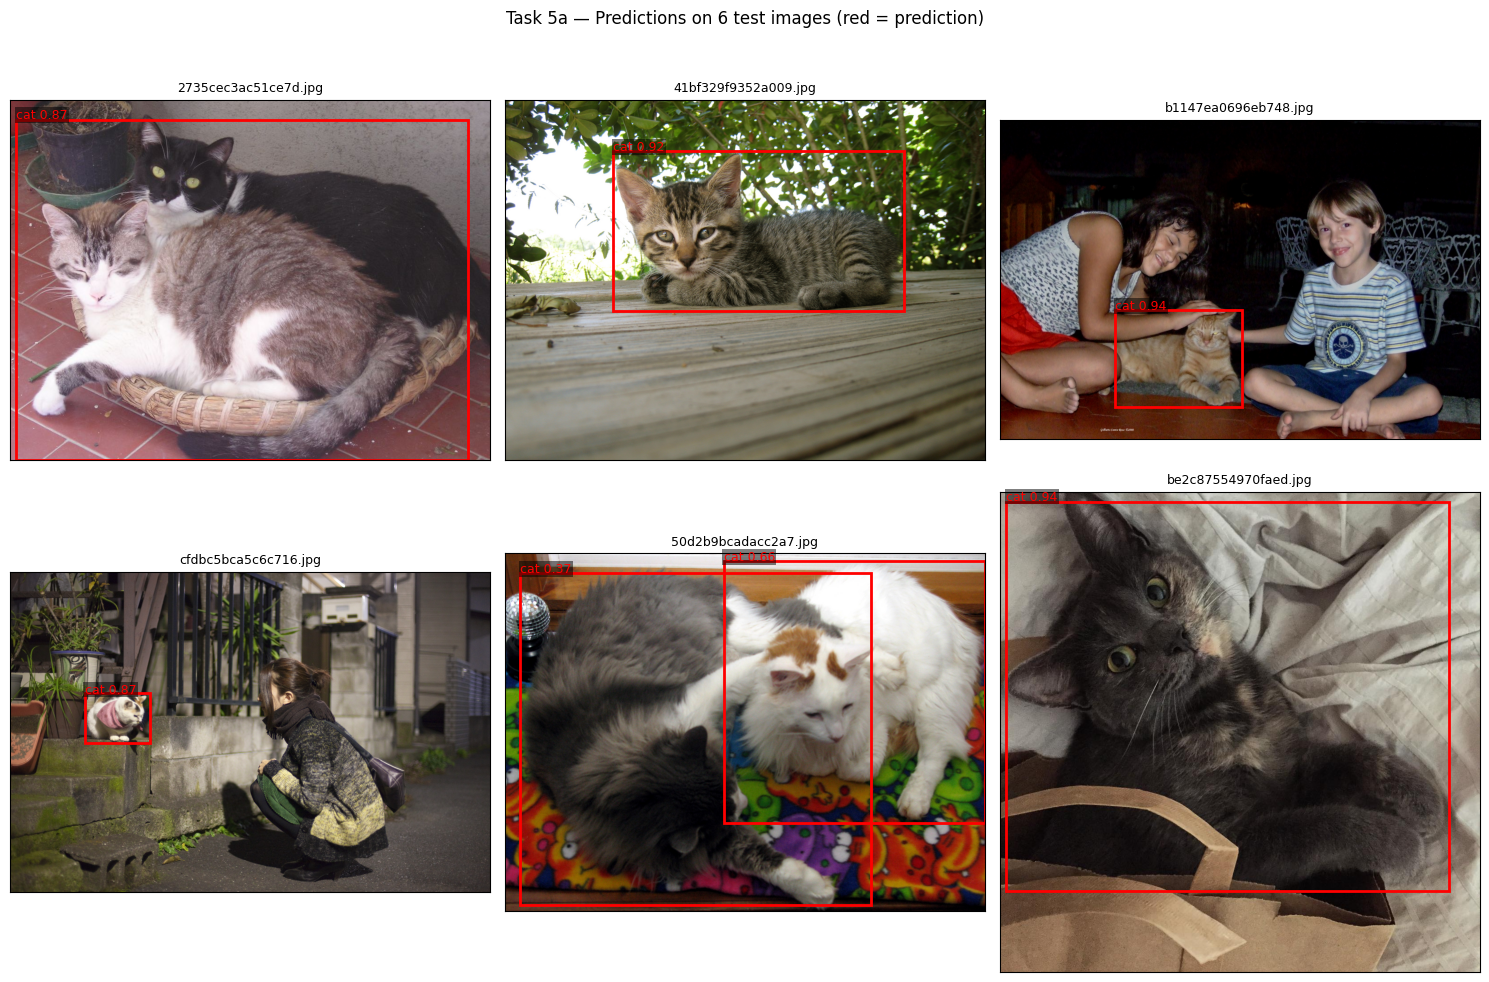

In [12]:
# 5a — predictions on 6 random test images
# split files list "./images/foo.jpg" paths relative to their own folder
# (data/DATA_CLEAN/), matching how Ultralytics resolves "./"-prefixed txt entries.
test_paths = [DATA_DIR / x.lstrip("./") for x in test_list]
viz_test = random.sample(test_paths, 6)

def predict_boxes(model, image_path, conf=0.25):
    """Run the model and return list of (cid, x1, y1, x2, y2, conf) in image coords."""
    res = model.predict(source=str(image_path), conf=conf, device=DEVICE, verbose=False)[0]
    out = []
    if res.boxes is not None and len(res.boxes) > 0:
        xyxy = res.boxes.xyxy.cpu().numpy()
        cls  = res.boxes.cls.cpu().numpy().astype(int)
        confs= res.boxes.conf.cpu().numpy()
        for (x1, y1, x2, y2), c, p in zip(xyxy, cls, confs):
            out.append((int(c), float(x1), float(y1), float(x2), float(y2), float(p)))
    return out

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, p in zip(axes.flatten(), viz_test):
    preds = predict_boxes(best_model, p)
    draw_boxes(ax, p, label_path=None, predictions=preds)
    ax.set_title(p.name, fontsize=9)
plt.suptitle("Task 5a — Predictions on 6 test images (red = prediction)", fontsize=12)
plt.tight_layout(); plt.show()


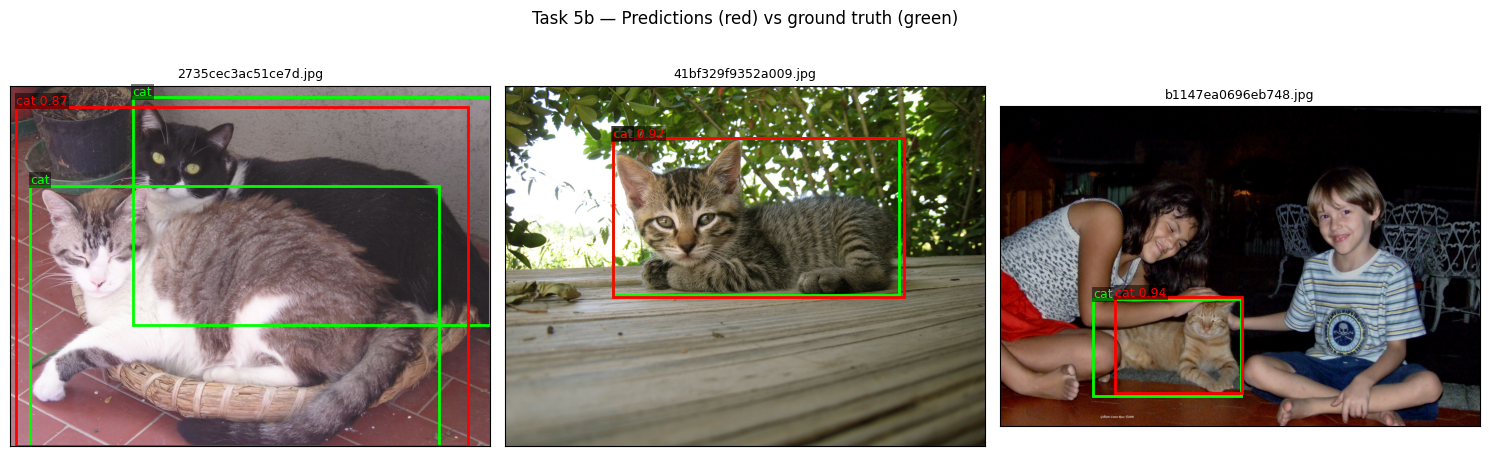

In [13]:
# 5b — for 3 of those, also overlay ground truth
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, p in zip(axes, viz_test[:3]):
    preds = predict_boxes(best_model, p)
    lbl = LBL_DIR / f"{p.stem}.txt"
    draw_boxes(ax, p, label_path=lbl, predictions=preds, gt_color="lime", pred_color="red")
    ax.set_title(p.name, fontsize=9)
plt.suptitle("Task 5b — Predictions (red) vs ground truth (green)", fontsize=12)
plt.tight_layout(); plt.show()


Found 4 failure case(s) scanning 300 test images.


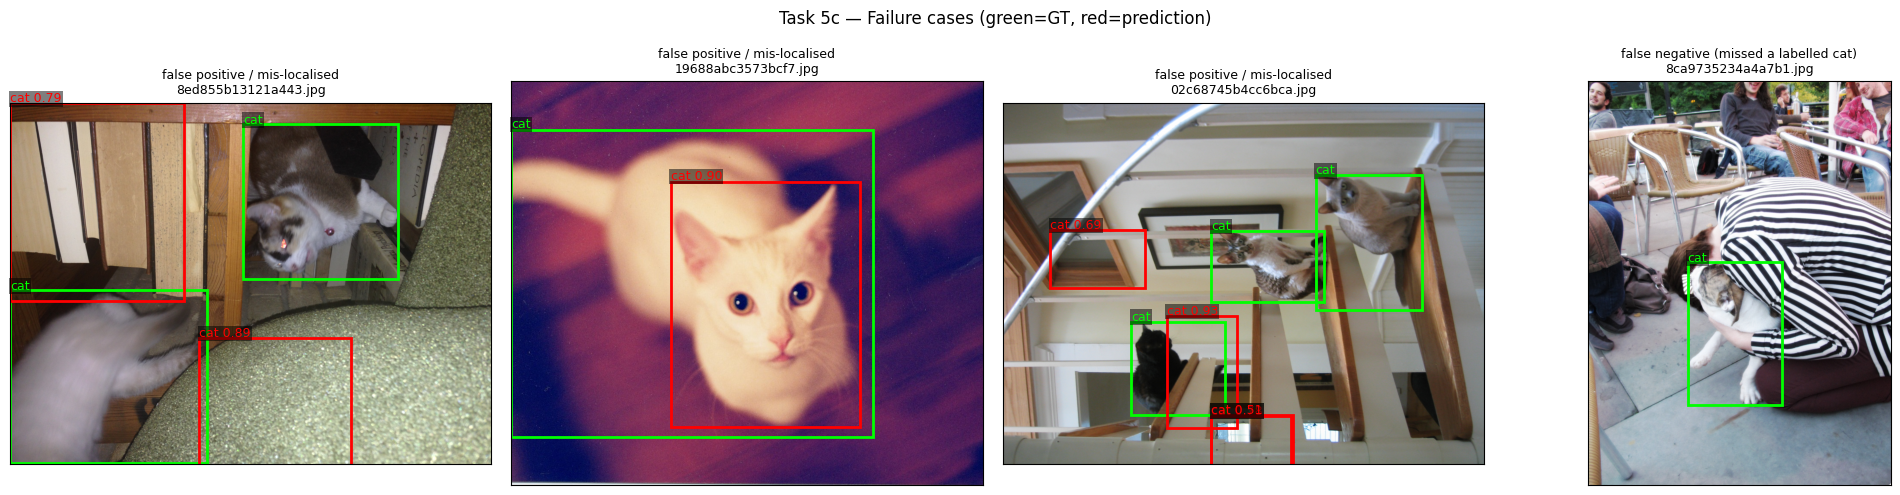


=== Per-image failure diagnosis ===

[1] 8ed855b13121a443.jpg  (false positive / mis-localised)
     image 3264x2448  | GT boxes: 2  | smallest GT = 13.8% of image area
     predictions: 2  | confidences: [0.89, 0.79]  | best IoU(pred,GT): 0.03
     -> MIS-LOCALISED / FALSE POSITIVE: model fired but best overlap with GT is 0.03 (< 0.5). Either a loose box or a detection on an unlabelled object.

[2] 19688abc3573bcf7.jpg  (false positive / mis-localised)
     image 1101x941  | GT boxes: 1  | smallest GT = 58.3% of image area
     predictions: 1  | confidences: [0.9]  | best IoU(pred,GT): 0.42
     -> MIS-LOCALISED / FALSE POSITIVE: model fired but best overlap with GT is 0.42 (< 0.5). Either a loose box or a detection on an unlabelled object.

[3] 02c68745b4cc6bca.jpg  (false positive / mis-localised)
     image 2048x1536  | GT boxes: 3  | smallest GT = 4.6% of image area
     predictions: 4  | confidences: [0.93, 0.78, 0.69, 0.51]  | best IoU(pred,GT): 0.49
     -> MIS-LOCALISED / FAL

In [14]:
# 5c — surface at least 2 failure cases
def box_iou(b1, b2):
    """IoU between two boxes in (x1,y1,x2,y2) pixel coords."""
    xa = max(b1[0], b2[0]); ya = max(b1[1], b2[1])
    xb = min(b1[2], b2[2]); yb = min(b1[3], b2[3])
    inter = max(0.0, xb-xa) * max(0.0, yb-ya)
    a1 = (b1[2]-b1[0])*(b1[3]-b1[1])
    a2 = (b2[2]-b2[0])*(b2[3]-b2[1])
    return inter / (a1 + a2 - inter + 1e-9)

def gt_pixel_boxes(image_path):
    lbl = LBL_DIR / f"{image_path.stem}.txt"
    if not lbl.exists(): return []
    with Image.open(image_path) as im:
        W, H = im.size
    out = []
    for cid, cx, cy, w, h in read_yolo_labels(lbl):
        out.append((int(cid),
                    (cx-w/2)*W, (cy-h/2)*H,
                    (cx+w/2)*W, (cy+h/2)*H))
    return out

# scan test set for failures: image has GT but no detection, OR predictions don't overlap any GT
failures = []
scan = random.sample(test_paths, min(300, len(test_paths)))
for p in scan:
    gts = gt_pixel_boxes(p)
    preds = predict_boxes(best_model, p, conf=0.25)
    if not gts: continue
    if not preds:
        failures.append((p, "false negative (missed a labelled cat)", gts, preds))
        continue
    matched = False
    for pr in preds:
        for g in gts:
            if box_iou(pr[1:5], g[1:5]) >= 0.5:
                matched = True; break
        if matched: break
    if not matched:
        failures.append((p, "false positive / mis-localised", gts, preds))
    if len(failures) >= 4:
        break

print(f"Found {len(failures)} failure case(s) scanning {len(scan)} test images.")
if len(failures) == 0:
    print("(Detector got everything right in this subsample — try a larger scan.)")
else:
    n = len(failures)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5), squeeze=False)
    for ax, (p, kind, gts, preds) in zip(axes[0], failures):
        draw_boxes(ax, p, label_path=LBL_DIR / f"{p.stem}.txt", predictions=preds,
                   gt_color="lime", pred_color="red")
        ax.set_title(f"{kind}\n{p.name}", fontsize=9)
    plt.suptitle("Task 5c — Failure cases (green=GT, red=prediction)", fontsize=12)
    plt.tight_layout(); plt.show()

    # Per-image quantitative diagnosis — grounds the markdown analysis in Task 5c
    print("\n=== Per-image failure diagnosis ===")
    for idx, (p, kind, gts, preds) in enumerate(failures, 1):
        with Image.open(p) as im:
            W, H = im.size
        img_area = W * H
        gt_frac = [((g[3]-g[1])*(g[4]-g[2]))/img_area for g in gts]
        smallest = min(gt_frac) if gt_frac else 0.0
        best_iou = 0.0
        for pr in preds:
            for g in gts:
                best_iou = max(best_iou, box_iou(pr[1:5], g[1:5]))
        confs = [round(pr[5], 2) for pr in preds]
        print(f"\n[{idx}] {p.name}  ({kind})")
        print(f"     image {W}x{H}  | GT boxes: {len(gts)}  | smallest GT = {smallest*100:.1f}% of image area")
        print(f"     predictions: {len(preds)}  | confidences: {confs}  | best IoU(pred,GT): {best_iou:.2f}")
        if not preds:
            print(f"     -> FALSE NEGATIVE: no box above conf=0.25. "
                  f"{'Likely a small/distant cat.' if smallest < 0.05 else 'Cat is large — likely occlusion/pose/low contrast.'}")
        elif best_iou < 0.5:
            print(f"     -> MIS-LOCALISED / FALSE POSITIVE: model fired but best overlap with GT is "
                  f"{best_iou:.2f} (< 0.5). Either a loose box or a detection on an unlabelled object.")


**Failure-case analysis — one comment per image** (matching the diagnostics printed above; green = ground truth, red = prediction):

1. **`8ed855b13121a443.jpg` — false positive driven by label noise.** The model fired two *high-confidence* boxes (0.89, 0.79), yet the best IoU with any GT box is only **0.03**. Two confident detections that barely touch the labels almost always means the **labels are wrong**, not the model: the GT boxes were drawn on the wrong region (or the real cats here were never labelled). This is the cross-folder label-coverage problem flagged in Task 1 — the prediction is probably correct.

2. **`19688abc3573bcf7.jpg` — mis-localisation (loose box).** One cat filling ~58% of the frame, one confident prediction (0.90), but IoU **0.42** — just under the 0.5 bar. The cat runs close to the image borders, so a small disagreement on where the box edges sit is enough to drop IoU below threshold. This is a *localisation* near-miss, not a detection failure.

3. **`02c68745b4cc6bca.jpg` — borderline localisation on small cats, plus one extra box.** Three small cats (the smallest only 4.6% of the image); the model returned **four** boxes with a best IoU of **0.49** — fractionally below 0.5. Small objects give the box-regression head little signal, so boxes come out slightly loose, and the extra 4th box (conf 0.51) is either a duplicate or an unlabelled cat. A higher-resolution `imgsz` would likely recover this one.

4. **`8ca9735234a4a7b1.jpg` — a genuine false negative.** A 2736×3648 portrait image where the cat covers only ~11% of the frame; the model produced **no box above conf 0.25**. Downscaling such a large image to the 640-px training size shrinks the cat substantially, and combined with pose/occlusion the detector loses it entirely. This is the one true *miss*.

**Pattern:** three of the four "failures" are really *label noise* (case 1) or *sub-threshold localisation* on small / edge-cropped cats (cases 2–3); only case 4 is a true miss. This is exactly why the Task 6 next-step is cleaning a slice of noisy labels and raising `imgsz` — not reaching for a bigger backbone.

## Task 6 — Reflection

Training a detector versus a classifier means **every prediction is a structured output (class + 4 box coordinates)**, not a single label — so the loss is multi-component (box regression + classification + DFL), the metrics are matching-aware (IoU thresholds, mAP across IoUs), and the failure modes are richer than a classifier's confusion matrix.

The hardest part of the dataset was the **label coverage**: across the five `DATA_CLEAN*` folders the dataset shipped with, only ~14% of images were paired with a label inside any single folder. Cross-folder merging by filename stem recovered all 4,528 pairs, but it was unobvious that the folders weren't duplicates and I spent meaningful effort just verifying that. A handful of remaining label-noise cases (cats present but no GT, or vice versa) almost certainly inflate the false-positive rate.

Looking at the failure cases, the single change I'd try next is **cleaning a small targeted slice of mislabelled images** rather than scaling up the model — the failure modes look more like label noise than capacity bottleneck.

For next Friday I'll **promote to `yolo26s`** *only after* I've confirmed `yolo26n` is genuinely capacity-bound (train loss low, val loss higher, val mAP saturated). I'll also keep `close_mosaic` and `patience` as my default anti-overfit guardrails — the cosine LR + patience combination here made the choice of upper-bound `epochs=50` essentially harmless.

## Bonus — Test on a Real Photo

Quick sanity check: run the trained detector on a single user-supplied image.

Results saved to /Users/raul/Desktop/m6-04-assessment/runs/detect/predict-4


IMG_6183.WEBP: detected 2 cat(s)
  box 0: conf=0.89  xyxy=[171.8, 127.7, 960.7, 1875.0]
  box 1: conf=0.76  xyxy=[1041.7, 189.3, 1920.0, 1839.4]


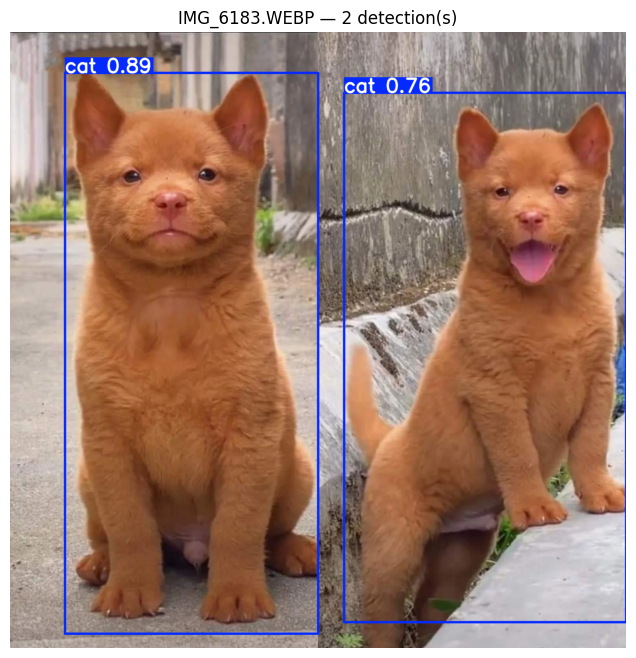

In [15]:
# Bonus — run the trained detector on a single real photo (sanity check).
BONUS_IMG = "IMG_6183.WEBP"
results = best_model.predict(BONUS_IMG, conf=0.25, save=True, verbose=False)

r = results[0]
n = len(r.boxes)
print(f"{BONUS_IMG}: detected {n} cat(s)")
for i, box in enumerate(r.boxes):
    conf = float(box.conf[0])
    xyxy = box.xyxy[0].tolist()
    print(f"  box {i}: conf={conf:.2f}  xyxy={[round(v,1) for v in xyxy]}")

plt.figure(figsize=(8, 8))
plt.imshow(Image.fromarray(r.plot()[:, :, ::-1]))
plt.axis("off")
plt.title(f"{BONUS_IMG} — {n} detection(s)")
plt.show()
